In [1]:
print("check")

check


Setup or fetch our ENV Variables

In [12]:
import os
from dotenv import load_dotenv
# Load .env file
load_dotenv()
# Groq --Model Provider
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

#search APi Key
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]=os.getenv("SERPER_API_KEY")

print("Keys are set !")


Keys are set !


In [46]:
from langchain.chat_models import init_chat_model

# Use Groq LLM
model = init_chat_model(
    model="groq:llama-3.3-70b-versatile",  # Large model for tool calling
    temperature=0.3
)

print("LLM initialized:", model)

LLM initialized: profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x000001CE232F9350> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CE23482D70> model_name='llama-3.3-70b-versatile' temperature=0.3 model_kwargs={} groq_api_key=SecretStr('**********')


SEARCH FUNCTIONALITY

In [27]:
from langchain_tavily import TavilySearch

# Initialize Tavily Search Tool
tavily_search = TavilySearch(
    max_results=5,
    topic="general"
)

print("Tavily search tool ready")



Tavily search tool ready


In [15]:
from langchain_community.utilities import GoogleSerperAPIWrapper
google_search=GoogleSerperAPIWrapper()

print("google serper is ready")

google serper is ready


test google serper 

In [16]:
result=google_search.run("best place to visit in goa travel guid")
print(result)

The tourism season in Goa goes on between November and February / March. These months will offer you the most frequency in tourism activities. Quiet Cavelossim · Dudhsager Falls & Spice Plantation · Peaceful Palolem · Our Final Evening In Goa · Travel Facts for Goa, India · Other Things to ... Popular Cities in Goa · Fontainhas Heritage Walk by Make It Happen · Goa Kayaking Sal Backwaters Mangroves Magic! · The Nature Trail At Chorao Island In Goa. 03 Mar Best Places to Visit in Goa, India · 1. Palolem · 2. Dolphin Watching · 3. Basilica Of Bom Jesus · 4. Watersports At Calangute · 5. Aguada ... Discover golden beaches, vibrant nightlife, Portuguese heritage, surfing spots and more in our Goa travel guide. Find top attractions and expert tips. 🏖️ Baga and Calangute Beaches These bustling beaches are perfect for water sports, beach shacks, and lively nightlife. Palolem Beach A serene ... Where India has colorful temples and adobe villages, Goa has bright white churches and Portuguese vi

In [ ]:
from langchain_tavily import TavilyResearch


response = TavilyResearch.invoke({"query": "latest AI news 2026"})
print(response)

{'query': 'latest AI news 2026', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.youtube.com/watch?v=-0i2ERMGoq4', 'title': 'AI in 2026 is going to be wild - YouTube', 'content': 'The latest AI News. Learn about LLMs, Gen AI and get ready for the rollout of AGI. Wes Roth covers the latest happenings in the world of', 'score': 0.9999443, 'raw_content': None}, {'url': 'https://www.crescendo.ai/news/latest-ai-news-and-updates', 'title': 'Latest AI News and AI Breakthroughs that Matter Most: 2026 & 2025', 'content': 'Summary: Apple has officially announced that a completely reimagined, AI-powered version of Siri is set to debut in 2026. This fundamental transformation will', 'score': 0.9999132, 'raw_content': None}, {'url': 'https://sigmatechnology.com/articles/tech-trends-in-2026-signals-not-noise/', 'title': 'Top Technology Trends 2026: The AI Era Redefined by Humans', 'content': 'By 2026, AI investments will mature from broad applications to h

In [ ]:
from langchain_core.tools import Tool 


def tavily_search_tool(query: str) -> str:
    """
    Search the web using Tavily for travel info, tips, attractions, etc.
    """
    # Call the existing TavilySearch tool underneath
    return tavily_search.invoke({"query": query}) # type: ignore


def google_serper_search_tool(query: str) -> str:
    """
    Search the web using Google Serper for up-to-date travel info.
    """
    return google_search.run(query) # type: ignore

In [30]:
tavily_search_tool("Plan a trip to india")

{'query': 'Plan a trip to india',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.foratravel.com/the-journal/planning-a-trip-to-india',
   'title': "A Beginner's Guide to Planning a Trip to India - Fora Travel",
   'content': 'From the moment I arrived, I was swept up in the sensory overload — vibrant colors, soul-stirring flavors, the hum of bustling people and a culture so rich it leaves you mesmerized. Here’s your beginner’s guide to India — what to expect, where to go and how to fall in love with it all. ## Day 2: Delhi in full color. We kicked off the day with a sunrise stroll through the Lodhi Art District — a living, breathing gallery where every wall tells a story. We dove headfirst into an Indian wedding experience, where we got to play bride for a day\xa0— think Bollywood dance lessons, sari embroidery and coffee cup astrology (yes, that’s a thing!). The journey took up quite a bit of our day, so we only had time for the Agra Fo

In [31]:
google_serper_search_tool("Plan a 5 trip to india")

"This five-day tour includes the best of India's Golden Triangle (Delhi, Agra, and Jaipur), including the Taj Mahal, the Red Fort, Jaipur's City Palace, and lots ... India Vacations & Trips from $3,481 · 1. Create memories in Delhi with a vacation package · 2. Explore New Delhi with a vacation package · 3. Enjoy Mumbai with a ... We are planning for a 5-6 days trip but kinda not sure on which part of India we should explore. Mostly want to have a quiet time with small treks and good ... We spent 5 Days in India's Tourist Triangle (Delhi, Agra, and Jaipur)! In this video we share our experiences in India and give tips to plan ... A Beginner's Guide to Planning a Trip to India · Day 1: Dive into Delhi · Day 2: Delhi in full color · Day 3: Road to Agra · Day 4: Taj Mahal magic. There are several 7-day trips that you can go to starting from Bangalore. · Plan 1 · Bangalore - Shimoga - Jog Falls (stay overnight) · Murudeshwar ... Explore India 5 to 7 Days for 2026 / 2027. Discover iconic sit

In [32]:
from langchain.agents import create_agent
system_prompt = """
You are a travel planner assistant. User asks travel queries like
'plan my trip to X', 'what to do in Y hotel', etc.
Always use the available web search tools (TavilySearch, GoogleSerperSearch)
to look up latest real-world travel info. Provide a helpful and clear itinerary/answers.
"""

Travel planner agent ready!


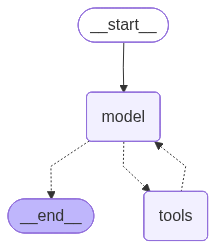

In [ ]:
agent = create_agent(
    model=model, # type: ignore
    tools=[tavily_search_tool , google_serper_search_tool],
    system_prompt=system_prompt.strip()
)
print("Travel planner agent ready!")
agent


In [49]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "Give me a 3 day plan for Kasol travel with places to see."}
    ]
})

print("Agent answer:\n")
print(response)

Agent answer:

{'messages': [HumanMessage(content='Give me a 3 day plan for Kasol travel with places to see.', additional_kwargs={}, response_metadata={}, id='0062604e-31b7-4047-96f0-dd97e754845f'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'sb4sqwcx1', 'function': {'arguments': '{"query":"Kasol travel plan 3 days"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'dygkxz96x', 'function': {'arguments': '{"query":"places to visit in Kasol"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'ysx89fxqv', 'function': {'arguments': '{"query":"Kasol latest travel updates"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 391, 'total_tokens': 458, 'completion_time': 0.150517656, 'completion_tokens_details': None, 'prompt_time': 0.070274374, 'prompt_tokens_details': None, 'queue_time': 0.048436835, 'total_time': 0.22079203}, 'model_name': 'llama-3.3-70b-versati

In [50]:
response["messages"]

[HumanMessage(content='Give me a 3 day plan for Kasol travel with places to see.', additional_kwargs={}, response_metadata={}, id='0062604e-31b7-4047-96f0-dd97e754845f'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'sb4sqwcx1', 'function': {'arguments': '{"query":"Kasol travel plan 3 days"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'dygkxz96x', 'function': {'arguments': '{"query":"places to visit in Kasol"}', 'name': 'tavily_search_tool'}, 'type': 'function'}, {'id': 'ysx89fxqv', 'function': {'arguments': '{"query":"Kasol latest travel updates"}', 'name': 'google_serper_search_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 391, 'total_tokens': 458, 'completion_time': 0.150517656, 'completion_tokens_details': None, 'prompt_time': 0.070274374, 'prompt_tokens_details': None, 'queue_time': 0.048436835, 'total_time': 0.22079203}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 

In [51]:
final_answer = response["messages"][-1].content
print(final_answer)

Here's a 3-day plan for Kasol travel with places to see:

Day 1: 
- Arrive in Kasol and check into your accommodation.
- Visit the Gurudwara Shri Manikaran Sahib, a sacred place for Sikhs.
- Explore the Parvati Valley and enjoy the scenic views of the river.

Day 2: 
- Trek to Chalal Village, a small and peaceful village near Kasol.
- Visit the Quaint Villages of Kalga, Pulga, and Tulga, known for their natural beauty and trekking trails.
- Enjoy the sunset at the riverside and relax in the evening.

Day 3: 
- Trek to Kheerganga, a popular trekking destination known for its hot springs and scenic views.
- Visit the Tosh Village, a small village located at the edge of the Parvati Valley.
- Return to Kasol in the evening and enjoy the local cuisine and culture.

Please note that the weather in Kasol in April is cold and humid but cool, with average highs of 47°F (8°C) and lows of 27°F (-3°C). It's recommended to check the current road conditions and weather forecast before planning your 